# ML-Ready EO Data Preparation using openEO

Training machine learning models on Earth Observation data requires large volumes of labelled samples with meaningful spectral and spatial features. Traditionally this involves downloading raw imagery, running preprocessing pipelines locally, and managing large intermediate files - a significant barrier for many users.

**openEO** removes this barrier by running all heavy computation in the cloud, directly on the data archive. You define a processing graph, openEO executes it server-side, and you download only the compact feature table or image chips you need for training.

---

## Workflow

```mermaid
flowchart TD
    GT["Ground truth labels\n(LUCAS 2022 parquet)"]

    GT --> CDSE

    subgraph CDSE["openEO on CDSE"]
        direction TB
        L["load Sentinel-2 L2A"]
        CM["cloud masking (SCL dilation)"]
        TC["temporal median composite"]
        UDF(apply custom process)
        IDX["spectral indices using built-in processes"]
        L --> CM --> TC --> UDF & IDX
    end

    CDSE --> AGG["aggregate_spatial"]
    CDSE --> PATCH["sample_by_feature"]

    AGG --> FT["Point features"]
    PATCH --> IC["Polygon patch outputs"]
```

---

## Notebook structure

| Part | Approach | Output | ML use |
|---|---|---|---|
| **A** | Point extraction | Feature table (CSV) | Random Forest, XGBoost |
| **B** | Polygon-based sampling | One raster per polygon | CNN, ViT, U-Net |

---

## Prerequisites

- Free [CDSE account](https://dataspace.copernicus.eu)
- Python: `openeo`, `geopandas`, `scikit-image`, `scikit-learn`
- Ground truth parquet is downloaded automatically from the CloudFerro URL in Section 2


In [1]:
# import necessary libraries
import openeo
import geopandas as gpd
import numpy as np
import pandas as pd
import json
import os
from pathlib import Path
from shapely.geometry import box
from openeo.extra.spectral_indices import compute_indices
from sklearn.model_selection import train_test_split

In [2]:
# connect to the cdse backend
conn = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
conn

Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

## 2 · Ground Truth: LUCAS 2022

We use the [LUCAS Copernicus 2022](https://data.jrc.ec.europa.eu/dataset/e3fe3cd0-44db-470e-8769-172a8b9e8874) survey as labelled ground truth.  
The notebook downloads the GeoParquet file, filters it to **Belgium**, and prepares both point- and polygon-based train/test splits from the same source data.

> **Adapting to your use case:** replace the parquet URL and bounding box with your own labelled dataset. Any GeoDataFrame with a `geometry` column and a `target` column works.


In [3]:
LUCAS_PQ_PATH = Path("LUCAS_2022_4326.parquet")
BELGIUM_BBOX = (2.5, 49.4, 6.5, 51.6)  # west, south, east, north

lucas = gpd.read_parquet(LUCAS_PQ_PATH)
west_b, south_b, east_b, north_b = BELGIUM_BBOX
lucas = lucas.cx[west_b:east_b, south_b:north_b].copy()

print(f"Loaded {len(lucas)} LUCAS polygons in Belgium  |  CRS: {lucas.crs.to_epsg()}")
lucas.head(3)

Loaded 5567 LUCAS polygons in Belgium  |  CRS: 4326


,point_id,user_id,point_nuts0,pi_extension,point_ex_ante,point_lat,point_long,point_altitude,point_copernicus,point_grassland,...,lu1_code,poly_area_sqm,surveycprncando,surveycprnlc1n,surveycprnclc1e,surveycprnclc1w,surveycprnclc1s,surveycprnlc,col_hex,geometry
765,38082954,FRSU236,FR,0,0,49.47599,2.910148,39,1,0,...,U120,3901.746495,1,17,21,40,51,C10,80ff00,"POLYGON ((2.90979 49.47575, 2.90978 49.47575, ..."
767,37883044,FRSU209,FR,0,0,50.26284,2.510591,141,1,0,...,U111,953.396090,1,32,6,10,6,B16,ffff00,"POLYGON ((2.51221 50.26185, 2.51221 50.26185, ..."
792,37943010,FRSU215,FR,0,0,49.96439,2.641608,80,1,0,...,U111,8208.436826,1,51,51,51,51,B11,ffd300,"POLYGON ((2.64112 49.96471, 2.64114 49.96472, ..."


In [4]:
# LUCAS 2022 uses 'survey_lc1' to map the classes
lc1_col = next((c for c in lucas.columns if c.lower() in ("lc1", "survey_lc1")), None)

# get the groundtruth data and convert geometry to centroid points
groundtruth = lucas[["point_id", lc1_col, "geometry"]].copy()
groundtruth["geometry"] = groundtruth["geometry"].apply(lambda x: x.centroid)
# get the target class as an integer (A=0, B=1, C=2, ...)
groundtruth["target"]   = groundtruth[lc1_col].apply(lambda x: ord(x[0]) - 65)

# work on a subset
counts = groundtruth["target"].value_counts()

# but I want to keep only the classes with at least 50 samples, and take the top 10 classes
top10_classes = counts[counts >= 50].head().index

# get the balanced groundtruth dataset with 10 samples per class
groundtruth_balanced = (
    groundtruth[groundtruth["target"].isin(top10_classes)]
    .groupby("target")
    .sample(n=10, random_state=42)
    .reset_index(drop=True)
)

groundtruth_train, groundtruth_test = train_test_split(groundtruth_balanced, test_size=0.25, random_state=333)
print(f"Train: {len(groundtruth_train)}  |  Test: {len(groundtruth_test)}")
print(f"{len(groundtruth_balanced)}, {groundtruth_balanced['target'].nunique()}, {groundtruth_balanced['target'].value_counts()}")

Train: 37  |  Test: 13
50, 5, target
0    10
1    10
2    10
4    10
5    10
Name: count, dtype: int64


## 3 · Part A: Point Feature Extraction

Extracts a **flat feature vector** per sample point using `aggregate_spatial`.  
The result is a JSON file that maps each sample to its feature values — directly loadable as a pandas DataFrame for model training.


In [5]:
BANDS   = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]
INDICES = ["NDVI", "EVI", "NDWI"]
TEXTURE_BANDS = ["contrast", "variance", "NDFI", "brightness"]

# get the AOI and temporal extent from the groundtruth training data
west, south, east, north = groundtruth_train.total_bounds
aoi = {"west": float(west), "south": float(south), "east": float(east), "north": float(north)}
temporal_extent = ["2022-06-01", "2022-10-31"]

In [6]:
# Load + cloud-mask Sentinel-2
s2 = conn.load_collection("SENTINEL2_L2A", temporal_extent=temporal_extent,
                            spatial_extent=aoi, bands=BANDS, max_cloud_cover=80)
scl = conn.load_collection("SENTINEL2_L2A", temporal_extent=temporal_extent,
                            spatial_extent=aoi, bands=["SCL"], max_cloud_cover=80)
cloud_mask = scl.process("to_scl_dilation_mask", data=scl,
                          kernel1_size=17, kernel2_size=77,
                          mask1_values=[2, 4, 5, 6, 7],
                          mask2_values=[3, 8, 9, 10, 11],
                          erosion_kernel_size=3)
s2_masked = s2.mask(cloud_mask)

In [7]:
# Temporal median composite 
composite = s2_masked.reduce_dimension(reducer="median", dimension="t")

In [8]:
indices_cube = compute_indices(composite, INDICES)

# udf to define custom  python processes
texture_udf = openeo.UDF.from_file("udf.py")
texture_cube = composite.apply_neighborhood(
    process=texture_udf,
    size=[
        {"dimension": "x", "value": 128, "unit": "px"},
        {"dimension": "y", "value": 128, "unit": "px"},
    ],
    overlap=[
        {"dimension": "x", "value": 32, "unit": "px"},
        {"dimension": "y", "value": 32, "unit": "px"},
    ],
    context={"padding_window_size": 33},
)
# merge the texture and indices cubes into a single feature cube
feature_cube = composite.merge_cubes(texture_cube).merge_cubes(indices_cube)

In [9]:
# aggregate_spatial: one feature vector per sample point
point_geojson = json.loads(groundtruth_train.set_geometry("geometry").to_json())
agg_cube = feature_cube.aggregate_spatial(point_geojson, reducer="median")

In [34]:
OUTPUT_POINTS = "point_based_features.csv"

# Submit batch job to CDSE 
agg_cube.execute_batch(title="point extraction", outputfile=OUTPUT_POINTS)
print(f"Saved → {OUTPUT_POINTS}")

0:00:00 Job 'j-260812104220440991adcecd77477e02': send 'start'
0:00:02 Job 'j-260812104220440991adcecd77477e02': queued (progress 0%)
0:00:07 Job 'j-260812104220440991adcecd77477e02': queued (progress 0%)
0:00:13 Job 'j-260812104220440991adcecd77477e02': queued (progress 0%)
0:00:22 Job 'j-260812104220440991adcecd77477e02': queued (progress 0%)
0:00:31 Job 'j-260812104220440991adcecd77477e02': queued (progress 0%)
0:00:44 Job 'j-260812104220440991adcecd77477e02': queued (progress 0%)
0:00:59 Job 'j-260812104220440991adcecd77477e02': running (progress N/A)
0:01:19 Job 'j-260812104220440991adcecd77477e02': running (progress N/A)
0:01:43 Job 'j-260812104220440991adcecd77477e02': running (progress N/A)
0:02:13 Job 'j-260812104220440991adcecd77477e02': running (progress N/A)
0:02:50 Job 'j-260812104220440991adcecd77477e02': running (progress N/A)
0:03:37 Job 'j-260812104220440991adcecd77477e02': running (progress N/A)
0:04:35 Job 'j-260812104220440991adcecd77477e02': running (progress N/A)


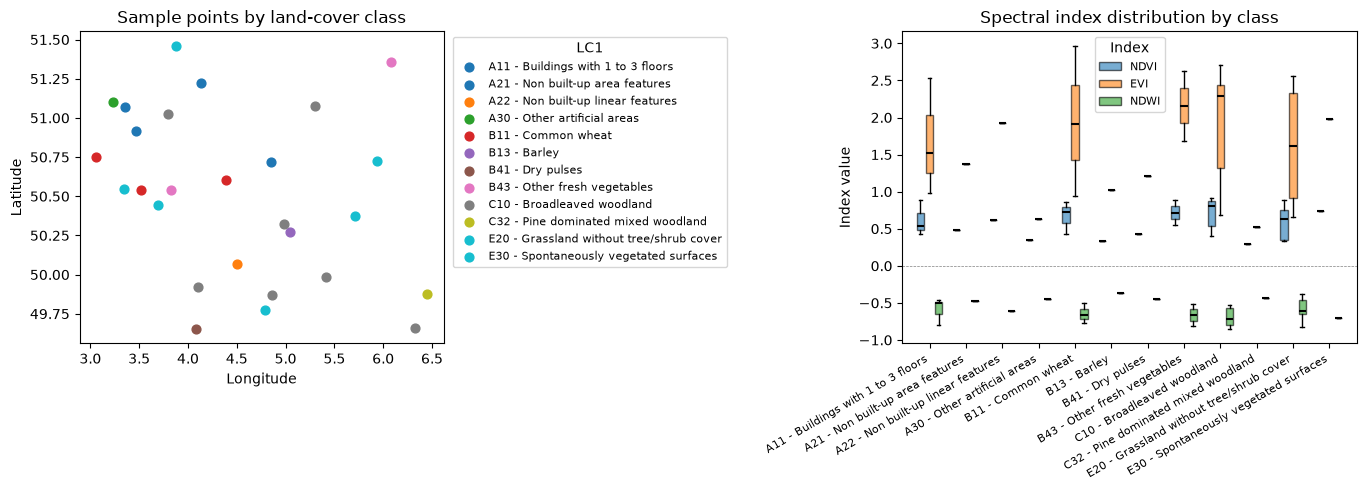

Feature table shape: (37, 21)  |  classes: 12


In [10]:
from plot_func import plot_point_features_stats
plot_point_features_stats("point_based_features.csv", groundtruth_train, lc1_col)

## 4 · Part B: Patch Feature Extraction

Extracts one image output per training polygon using `sample_by_feature=True`.  
This version reuses the polygon split prepared in Section 2, so there is no second data-loading block here.

> If you want fixed-size chips centred on points instead of polygon footprints, reintroduce a centroid-plus-buffer geometry step here.

In [13]:
# define the patch size and buffer size in meters (for 10 m/px Sentinel-2)
PATCH_SIZE_PX = 64
BUFFER_M = ((PATCH_SIZE_PX * 10) / 2)-5

patches = groundtruth_train.to_crs(32631).copy()

# create square patches around the centroid points
patches["geometry"] = patches.geometry.centroid.buffer(BUFFER_M, cap_style=3)
patches = patches.to_crs(4326)

# create a patch_id column for each patch as identifier for the patch
patches["patch_id"] = patches["point_id"].astype(str)
patches.head(3)

,point_id,survey_lc1,geometry,target,patch_id
10,38623068,B11 - Common wheat,"POLYGON ((3.52006 50.54348, 3.52 50.53781, 3.5...",1,38623068
47,38183098,F40 - Other bare soil,"POLYGON ((2.86098 50.77525, 2.861 50.76958, 2....",5,38183098
1,38563128,A11 - Buildings with 1 to 3 floors,"POLYGON ((3.35934 51.07565, 3.35929 51.06998, ...",0,38563128


In [14]:
west_p, south_p, east_p, north_p = patches.total_bounds
patch_aoi = {"west": float(west_p), "south": float(south_p),
             "east": float(east_p),  "north": float(north_p)}

In [15]:
s2_p = conn.load_collection("SENTINEL2_L2A", temporal_extent=temporal_extent,
                              spatial_extent=patch_aoi, bands=BANDS, max_cloud_cover=80)
scl_p = conn.load_collection("SENTINEL2_L2A", temporal_extent=temporal_extent,
                              spatial_extent=patch_aoi, bands=["SCL"], max_cloud_cover=80)
cm_p = scl_p.process("to_scl_dilation_mask", data=scl_p,
                        kernel1_size=17, kernel2_size=77,
                        mask1_values=[2, 4, 5, 6, 7],
                        mask2_values=[3, 8, 9, 10, 11],
                        erosion_kernel_size=3)

composite_p = s2_p.mask(cm_p).reduce_dimension(reducer="median", dimension="t")

In [16]:
texture_p = composite_p.apply_neighborhood(
    process=openeo.UDF.from_file("udf.py"),
    size=[{"dimension": "x", "value": 128, "unit": "px"},
          {"dimension": "y", "value": 128, "unit": "px"}],
    overlap=[{"dimension": "x", "value": 32, "unit": "px"},
             {"dimension": "y", "value": 32, "unit": "px"}],
    context={"padding_window_size": 33},
)
feature_patch = composite_p.merge_cubes(texture_p).merge_cubes(
    compute_indices(composite_p, INDICES)
)

In [17]:
patch_cube = feature_patch.filter_spatial(json.loads(patches.to_json()))

In [23]:
OUTPUT_PATCH_DIR = "patch_extracted"
os.makedirs(OUTPUT_PATCH_DIR, exist_ok=True)

# Export one GeoTIFF per training polygon.
job = patch_cube.create_job(
    out_format="GTiff",
    title="Patch Extraction",
    sample_by_feature=True,
    feature_id_property="patch_id",
    job_options={"driver-memory": "2G", "executor-memory": "2G", "max-executors": 10},
)
job.start_and_wait()
job.get_results().download_files(OUTPUT_PATCH_DIR)

print(f"Saved polygon-based patch outputs in {OUTPUT_PATCH_DIR}")

0:00:00 Job 'j-2608121256424988b0a701f946757e49': send 'start'
0:00:02 Job 'j-2608121256424988b0a701f946757e49': created (progress 0%)
0:00:07 Job 'j-2608121256424988b0a701f946757e49': queued (progress 0%)
0:00:13 Job 'j-2608121256424988b0a701f946757e49': queued (progress 0%)
0:00:21 Job 'j-2608121256424988b0a701f946757e49': queued (progress 0%)
0:00:31 Job 'j-2608121256424988b0a701f946757e49': running (progress N/A)
0:00:44 Job 'j-2608121256424988b0a701f946757e49': running (progress N/A)
0:00:59 Job 'j-2608121256424988b0a701f946757e49': running (progress N/A)
0:01:18 Job 'j-2608121256424988b0a701f946757e49': running (progress N/A)
0:01:42 Job 'j-2608121256424988b0a701f946757e49': running (progress N/A)
0:02:12 Job 'j-2608121256424988b0a701f946757e49': running (progress N/A)
0:02:50 Job 'j-2608121256424988b0a701f946757e49': running (progress N/A)
0:03:36 Job 'j-2608121256424988b0a701f946757e49': running (progress N/A)
0:04:35 Job 'j-2608121256424988b0a701f946757e49': running (progress 

In [18]:
from plot_func import plot_single_patch_as_rgb, plot_patches_with_polygons

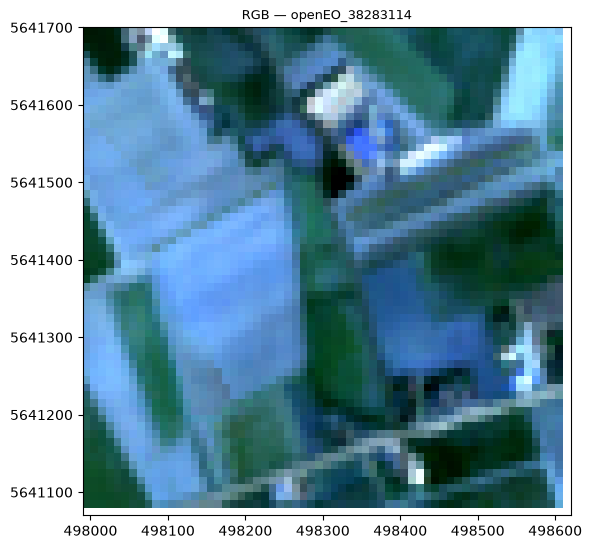

In [20]:
plot_single_patch_as_rgb("patch_extracted_s2/openEO_38283114.tif")

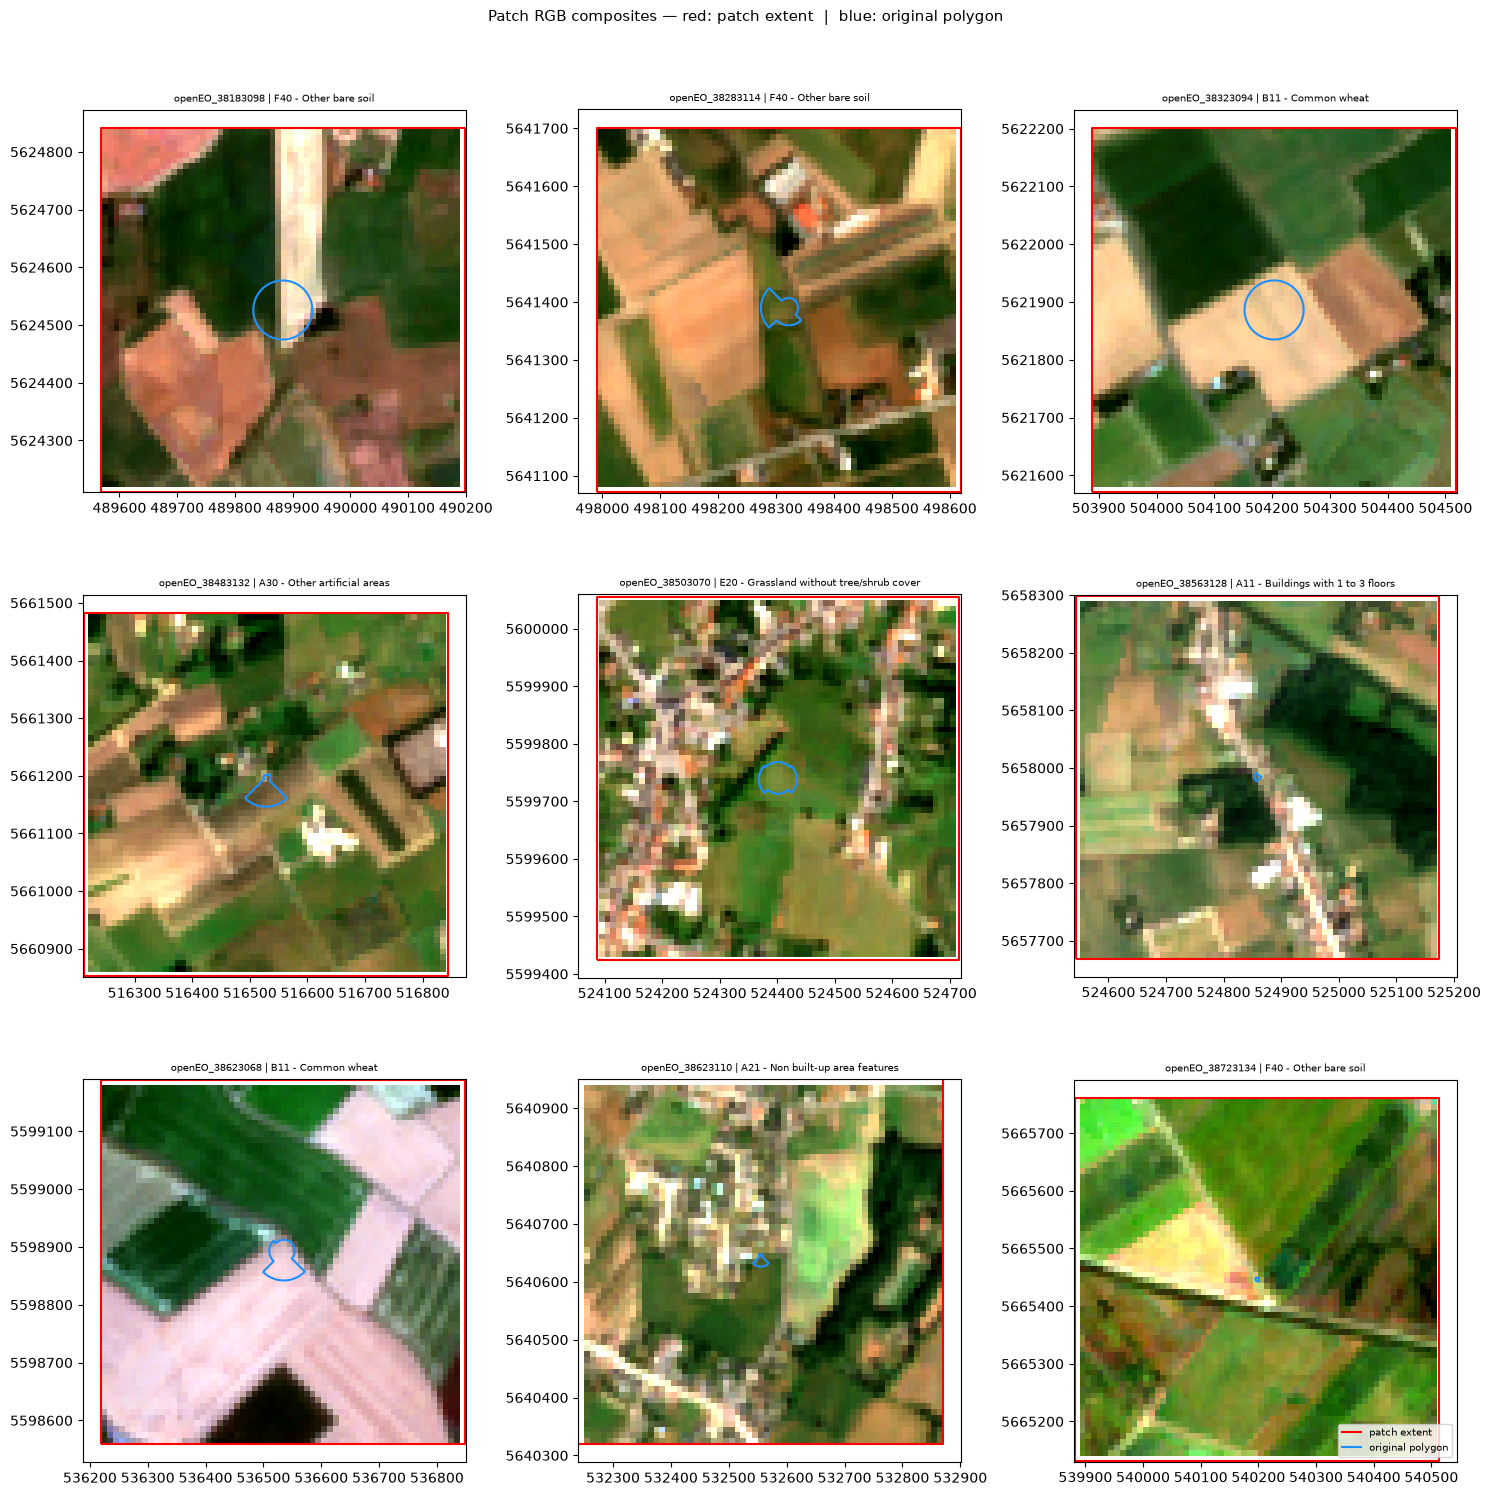

In [ ]:
plot_patches_with_polygons(OUTPUT_PATCH_DIR, patches, lucas, lc1_col)